## Introduction

Mobile carrier Megaline has found out that many of their subscribers use legacy plans. They want to develop a model that would analyze subscribers' behavior and recommend one of Megaline's newer plans: Smart or Ultra. 

In this project I will be analyzing the data to see what the best recommendation for their newer plans: Smart or Ultra.

The threshold for accuracy for the model we will be using is 0.75.

## Importing libraries and data.

In [1]:
# Importing necessary libraries and functions.
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import math
from scipy import stats as sts
import matplotlib.pyplot as plt

In [2]:
# Loading in the dataframes.
df = pd.read_csv('datasets/users_behavior.csv')

In [3]:
# Checking the data frames
display(df)
display(df.info())

,calls,minutes,messages,mb_used,is_ultra
0,40.0,311.90,83.0,19915.42,0
1,85.0,516.75,56.0,22696.96,0
2,77.0,467.66,86.0,21060.45,0
3,106.0,745.53,81.0,8437.39,1
4,66.0,418.74,1.0,14502.75,0
...,...,...,...,...,...
3209,122.0,910.98,20.0,35124.90,1
3210,25.0,190.36,0.0,3275.61,0
3211,97.0,634.44,70.0,13974.06,0
3212,64.0,462.32,90.0,31239.78,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB


None

## Splitting the data

In [4]:
# Splitting the data into training set, validation set, and test set.
train_df, temp_df = train_test_split(df, test_size=0.4, random_state=12345)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=12345)

In [5]:
display(val_df.info)

<bound method DataFrame.info of       calls  minutes  messages   mb_used  is_ultra
1386   92.0   536.96      18.0  20193.90         0
3124   40.0   286.57      17.0  17918.75         0
1956   81.0   531.22      56.0  17755.06         0
2286   67.0   460.76      27.0  16626.26         0
3077   22.0   120.09      16.0   9039.57         0
...     ...      ...       ...       ...       ...
1999   56.0   398.45       4.0  23682.94         0
1023   76.0   601.10       0.0  17104.36         0
748    81.0   525.97      15.0  18878.91         0
1667   10.0    63.03       0.0   2568.00         1
3197   89.0   660.72      68.0  11711.54         0

[643 rows x 5 columns]>

In [6]:
# Features and Target
train_target = train_df['is_ultra']
train_features = train_df.drop('is_ultra', axis=1)

val_target = val_df['is_ultra']
val_features = val_df.drop('is_ultra', axis=1)

test_target = test_df['is_ultra']
test_features = test_df.drop('is_ultra', axis=1)

## Investigating the different models.

In [7]:
# Checking acurracy for Decision Tree.
best_depth_dt = 0
best_result_dt = 0
for depth in range(1, 21):
    model_dt = DecisionTreeClassifier(random_state=54321, max_depth=depth) # create a model with the given depth
    model_dt.fit(train_features, train_target) # train the model
    predictions_dt = model_dt.predict(val_features) # get the model's predictions
    result_dt = accuracy_score(val_target, predictions_dt) # calculate the accuracy
    print("max_depth =", depth, ":", result_dt)
    if result_dt > best_result_dt:
        best_depth_dt = depth
        best_result_dt = result_dt
print('Best depth =', best_depth_dt, ':', best_result_dt)

max_depth = 1 : 0.7542768273716952
max_depth = 2 : 0.7822706065318819
max_depth = 3 : 0.7853810264385692
max_depth = 4 : 0.7791601866251944
max_depth = 5 : 0.7791601866251944
max_depth = 6 : 0.7838258164852255
max_depth = 7 : 0.7822706065318819
max_depth = 8 : 0.7822706065318819
max_depth = 9 : 0.7838258164852255
max_depth = 10 : 0.776049766718507
max_depth = 11 : 0.7573872472783826
max_depth = 12 : 0.76049766718507
max_depth = 13 : 0.7542768273716952
max_depth = 14 : 0.7589424572317263
max_depth = 15 : 0.749611197511664
max_depth = 16 : 0.7216174183514774
max_depth = 17 : 0.7247278382581649
max_depth = 18 : 0.7231726283048211
max_depth = 19 : 0.7293934681181959
max_depth = 20 : 0.71850699844479
Best depth = 3 : 0.7853810264385692


In [8]:
# Checking accuracy for Random Forest
best_score_rf = 0
best_est_rf = 0
for est in range(1, 101): # choose hyperparameter range
    model_rf = RandomForestClassifier(random_state=54321, n_estimators=est) # set number of trees
    model_rf.fit(train_features, train_target) # train model on training set
    score_rf = model_rf.score(val_features, val_target) # calculate accuracy score on validation set
    if score_rf > best_score_rf:
        best_score_rf = score_rf # save best accuracy score on validation set
        best_est_rf = est # save number of estimators corresponding to best accuracy score

print("Accuracy of the best model on the validation set (n_estimators = {}): {}".format(best_est_rf, best_score_rf))

final_model_rf = RandomForestClassifier(random_state=54321, n_estimators=best_est_rf) # change n_estimators to get best model
final_model_rf.fit(train_features, train_target)

Accuracy of the best model on the validation set (n_estimators = 40): 0.80248833592535


RandomForestClassifier(n_estimators=40, random_state=54321)

In [9]:
# Logistic Regression
model_lr =  LogisticRegression(random_state=54321, solver='liblinear')# initialize logistic regression constructor with parameters random_state=54321 and solver='liblinear'
model_lr.fit(train_features,train_target)  # train model on training set
score_train_lr = model_lr.score(train_features, train_target
    # calculate accuracy score on training set
)  
score_valid_lr = model_lr.score(val_features, val_target
    # calculate accuracy score on validation set
)  

print(
    "Accuracy of the logistic regression model on the training set:",
    score_train_lr,
)
print(
    "Accuracy of the logistic regression model on the validation set:",
    score_valid_lr,
)

Accuracy of the logistic regression model on the training set: 0.7510373443983402
Accuracy of the logistic regression model on the validation set: 0.7573872472783826


## Checking the quality of the model with test sample.

In [10]:
# Predict on test data using the best model
test_predictions = final_model_rf.predict(test_features)
test_accuracy = accuracy_score(test_target, test_predictions)
print("Accuracy of the best model on the test set:", test_accuracy)

# Additional metrics can also be calculated
print(classification_report(test_target, test_predictions))


Accuracy of the best model on the test set: 0.7931570762052877
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       440
           1       0.72      0.57      0.63       203

    accuracy                           0.79       643
   macro avg       0.77      0.73      0.74       643
weighted avg       0.79      0.79      0.79       643



## Investigating of data.

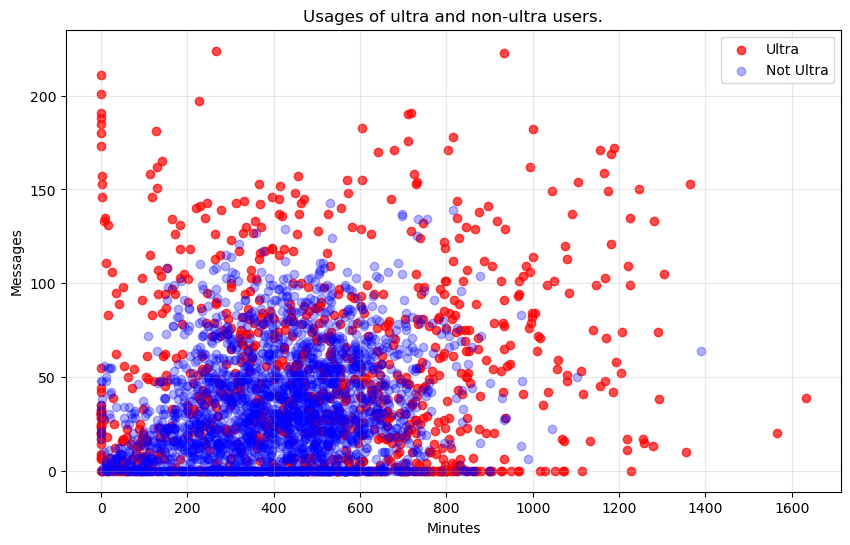

In [11]:
plt.figure(figsize=(10, 6))  # Adjust figure size for better visibility

# Separate data based on 'is_ultra'
ultra_data = df[df['is_ultra'] == 1]
non_ultra_data = df[df['is_ultra'] == 0]

# Plot for 'is_ultra' == 1 (e.g., red color)
plt.scatter(ultra_data['minutes'], ultra_data['messages'], color='red', label='Ultra', alpha=0.7)

# Plot for 'is_ultra' == 0 (e.g., blue color)
plt.scatter(non_ultra_data['minutes'], non_ultra_data['messages'], color='blue', label='Not Ultra', alpha=0.3)

# Add labels, title, and legend
plt.xlabel('Minutes')
plt.ylabel('Messages')
plt.title('Usages of ultra and non-ultra users.')
plt.legend()
plt.grid(alpha=0.3)  # Add a light grid for better readability

# Show plot
plt.show()


A quick cursory glance at a scatter plot confirms some of hte findings in the model. Additionally, based on the scatter plot of Ultra and Surf users, it looks like for the most part Surf plan users tend to use less minutes and messages as a whole group, while Ultra users are all over the place.

## Wrap up

For the breakdown, I chose to break up the data frame into 60% training, 20% validation, and 20% test data. I targeted the is_ultra column since that was the information we wanted to look into.  Additionally, I did a quick scatter plot to look at the ultra users and surf plan users. It looks like there are some outliers for surf users that can be easily converted to ultra users. The Random Forest had the highest accuracy rating based on all three models I tested. The optimal hyperparameter for the random forest was 40. Although this yielded a higher accuracy, it did require more time and complexity. If data sets and models become larger and 